# Outlier and influential observation sensitive analysis

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pickle

from thesis.correlation_sociodemographic_covid.util import save_model, summarize_results, \
    tunning_negative_binomial_model, outlier_analysis

## Loading data

In [2]:
df_variables = pd.read_csv('data/df_without_collinearity_standardized.csv', index_col=0)
df_variables = df_variables.drop(columns=['percentage_population_age_range_60_more', 'percentage_male_population'])

In [3]:
df_political = pd.read_csv('data/df_political_without_missing_points.csv', index_col=0)[['percentual_votes_for_bolsonaro']]

In [4]:
df_y = pd.read_csv('data/df_mortality.csv', index_col=0)

In [5]:
df_cluster_probabilities = pd.read_csv('data/df_standardized_pca_2spherical_5_probability.csv', index_col=0)
df_cluster_probabilities.columns = ['Semi-urbanized', 'Urbanized', 'Rural with high human development', 'Urbanized with informal settlements', 'Rural with low human development']

## Outlier and influential observation sensitivity Analysis


*** Period:  2020_1
\*** Model 6
===>Full model:
                    Generalized Linear Model Regression Results                    
Dep. Variable:     expected_deaths_1s_2020   No. Observations:                 3045
Model:                                 GLM   Df Residuals:                     3040
Model Family:             NegativeBinomial   Df Model:                            4
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -35980.
Date:                     Fri, 20 Jun 2025   Deviance:                       3377.8
Time:                             22:43:05   Pearson chi2:                 4.03e+03
No. Iterations:                          7   Pseudo R-squ. (CS):             0.3751
Covariance Type:                 nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
------

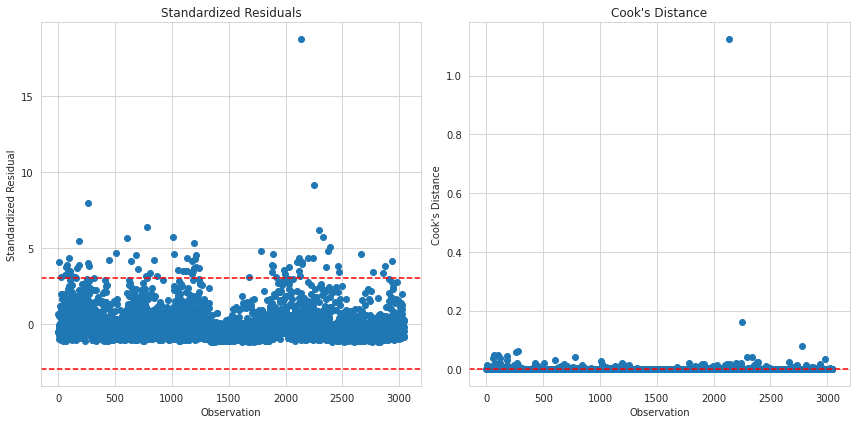

Quantity outliers (Standardized Residuals > 3): 80
Quantity influential Points (Cook's Distance > 4/n): 275
Selected alpha: 0.49
                    Generalized Linear Model Regression Results                    
Dep. Variable:     expected_deaths_1s_2020   No. Observations:                 2770
Model:                                 GLM   Df Residuals:                     2765
Model Family:             NegativeBinomial   Df Model:                            4
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -31829.
Date:                     Fri, 20 Jun 2025   Deviance:                       2982.4
Time:                             22:43:10   Pearson chi2:                 2.60e+03
No. Iterations:                          6   Pseudo R-squ. (CS):             0.4349
Covariance Type:                 nonrobust                                         
                               

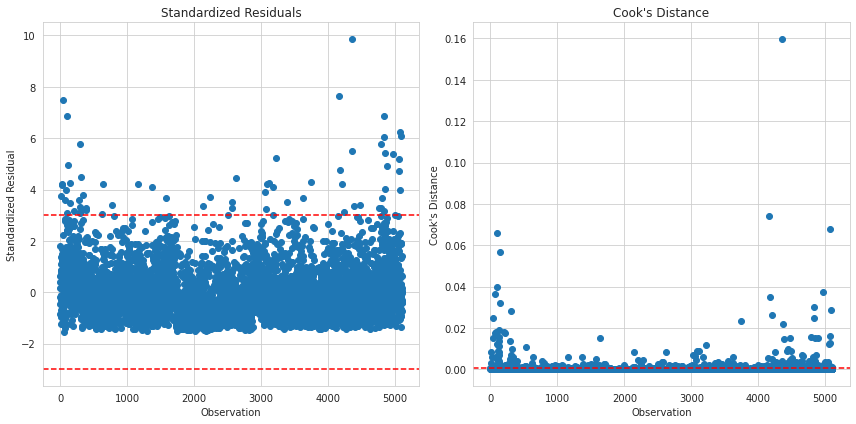

Quantity outliers (Standardized Residuals > 3): 66
Quantity influential Points (Cook's Distance > 4/n): 360
Selected alpha: 0.33
                  Generalized Linear Model Regression Results                   
Dep. Variable:     expected_deaths_2020   No. Observations:                 4750
Model:                              GLM   Df Residuals:                     4745
Model Family:          NegativeBinomial   Df Model:                            4
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -59159.
Date:                  Fri, 20 Jun 2025   Deviance:                       4935.9
Time:                          22:43:17   Pearson chi2:                 4.06e+03
No. Iterations:                       6   Pseudo R-squ. (CS):             0.2461
Covariance Type:              nonrobust                                         
                                          coef    std err    

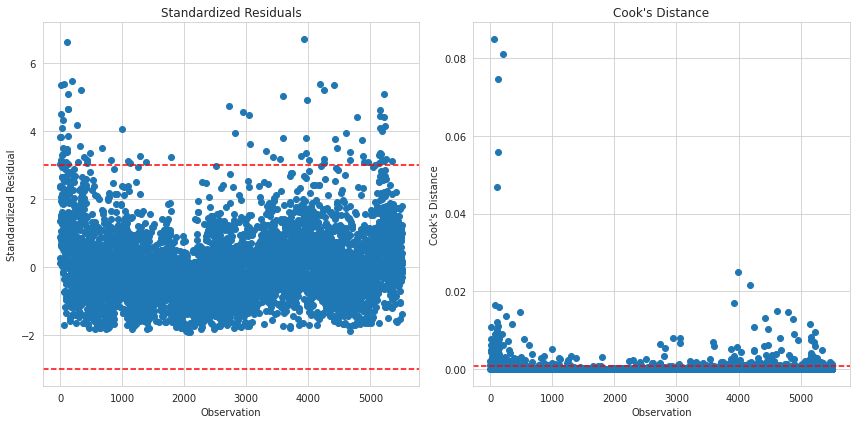

Quantity outliers (Standardized Residuals > 3): 86
Quantity influential Points (Cook's Distance > 4/n): 332
Selected alpha: 0.2
                  Generalized Linear Model Regression Results                   
Dep. Variable:     expected_deaths_2021   No. Observations:                 5183
Model:                              GLM   Df Residuals:                     5178
Model Family:          NegativeBinomial   Df Model:                            4
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -68346.
Date:                  Fri, 20 Jun 2025   Deviance:                       5416.7
Time:                          22:43:24   Pearson chi2:                 4.48e+03
No. Iterations:                       5   Pseudo R-squ. (CS):             0.4231
Covariance Type:              nonrobust                                         
                                          coef    std err     

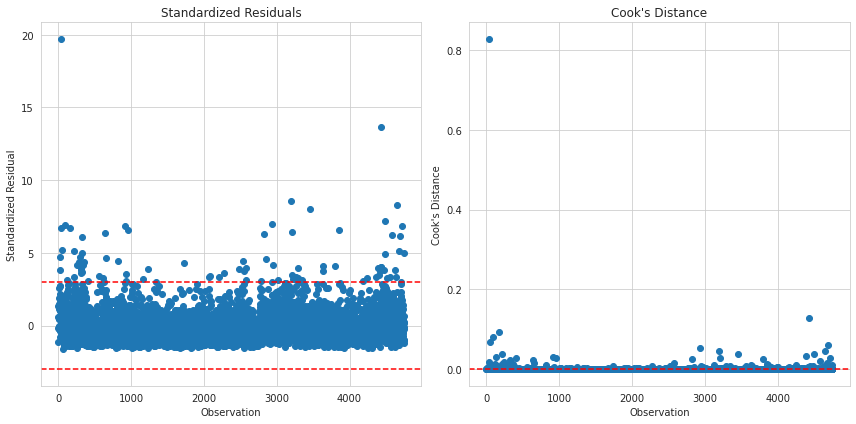

Quantity outliers (Standardized Residuals > 3): 87
Quantity influential Points (Cook's Distance > 4/n): 338
Selected alpha: 0.26
                  Generalized Linear Model Regression Results                   
Dep. Variable:     expected_deaths_2022   No. Observations:                 4413
Model:                              GLM   Df Residuals:                     4408
Model Family:          NegativeBinomial   Df Model:                            4
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -51348.
Date:                  Fri, 20 Jun 2025   Deviance:                       4664.2
Time:                          22:43:30   Pearson chi2:                 4.03e+03
No. Iterations:                       5   Pseudo R-squ. (CS):             0.2066
Covariance Type:              nonrobust                                         
                                          coef    std err    

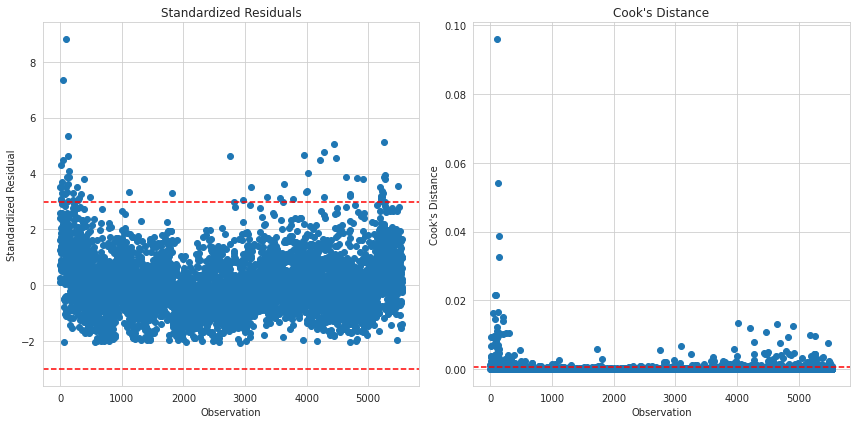

Quantity outliers (Standardized Residuals > 3): 65
Quantity influential Points (Cook's Distance > 4/n): 280
Selected alpha: 0.16
                   Generalized Linear Model Regression Results                    
Dep. Variable:     expected_deaths_entire   No. Observations:                 5272
Model:                                GLM   Df Residuals:                     5267
Model Family:            NegativeBinomial   Df Model:                            4
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -71461.
Date:                    Fri, 20 Jun 2025   Deviance:                       5460.4
Time:                            22:43:37   Pearson chi2:                 4.58e+03
No. Iterations:                         7   Pseudo R-squ. (CS):             0.3767
Covariance Type:                nonrobust                                         
                                         

In [6]:
list_columns_y = ['expected_deaths_1s_2020', 'expected_deaths_2020', 'expected_deaths_2021', 'expected_deaths_2022', 'expected_deaths_entire']
list_periods = ['2020_1','2020', '2021', '2022', '2020_2022']

for i in range(len(list_periods)):
    column_y = list_columns_y[i]
    period = list_periods[i]
    print('\n*** Period: ', period)
        
    y = df_y[column_y]

    # Model 6
    print('\*** Model 6')
    print('===>Full model:')
    with open('models/model_6_'+period+'.pkl', 'rb') as file:
        model = pickle.load(file)
    summarize_results(model)
    outliers, influential_points, cooks_d, standardized_residuals = outlier_analysis(model)

    x = df_cluster_probabilities.drop(columns=['Urbanized']).copy()
    x = sm.add_constant(x)

    x = x.loc[y>0]
    y = y.loc[y>0]

    positions_to_remove = list(set(np.concatenate([outliers, influential_points])))
    indices_to_remove = x.iloc[positions_to_remove].index
    x_without_outliers = x.drop(indices_to_remove)
    y_without_outliers = y.drop(indices_to_remove)

    model = tunning_negative_binomial_model(x_without_outliers,y_without_outliers,list_offset=None)
    filename = 'model_6_'+period
    save_model(model,filename,'models/sensitivity_analysis/outliers')
    summarize_results(model)

    # Model 11
    # print('\*** Model 11')
    # print('===>Full model:')
    # with open('models/model_11_'+period+'.pkl', 'rb') as file:
    #     model = pickle.load(file)
    # summarize_results(model)
    # outliers, influential_points, cooks_d, standardized_residuals = outlier_analysis(model)
    #
    # x = df_variables.copy()
    # scaler = StandardScaler()
    # percentage_votes_for_bolsonaro_standardized = scaler.fit_transform(df_political)
    # x['percentage_votes_for_bolsonaro'] = percentage_votes_for_bolsonaro_standardized[:,0]
    # x = sm.add_constant(x)
    #
    # x = x.loc[y>0]
    # y = y.loc[y>0]
    #
    # positions_to_remove = list(set(np.concatenate([outliers, influential_points])))
    # indices_to_remove = x.iloc[positions_to_remove].index
    # x_without_outliers = x.drop(indices_to_remove)
    # y_without_outliers = y.drop(indices_to_remove)
    #
    # model = tunning_negative_binomial_model(x_without_outliers,y_without_outliers, list_offset=None)
    # filename = 'model_11_'+period
    # save_model(model,filename,'models/sensitivity_analysis/outliers')
    # summarize_results(model)